## Week 8 Exercises

###<font color=green> Replace the name below with **your name**. For full credit, your total needs to add up to 100 points.

I highly recommend reading the accompanying pdf for programming notes and other important details.

# Kavin Kannan

In [3]:
import numpy as np
from numpy import sin, cos, exp, sqrt
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import odeint

1. Integration by Metropolis Algorithm (10 points)
Use the Metropolis algorithm to calculate the integral

Z
W(x) dx
for a non-negative real function W(x).
Do this for the case

W(x) = 1
1 + x
2

and reproduce the known result
Z ∞
−∞
dx
1 + x
2
= π .

2. SIR Model 15 points
It has been 5 years since the start of the largest disruption of normal
life that any of us had experienced in our lifetimes, caused by a virus,
SARS-CoV-2, which can lead to Covid-19 disease. At times like these,
epidemiologists are called upon to help public officials plan for ways
in which to mitigate the impact of the disease, and they do this using
predictive models. Since we are not epidemiologists, we will use a model
that forms the basis of much of the modeling being carried out today.
You can read more about these types of models on Wikipedia’s article
on Compartmental or Container models.
The original model formulated by Kermack and McKendrick in 19272,
tracks the spread of disease in a population by dividing people into
three basic compartments: Susceptible (S), Infected (I), and Recov-
ered/Removed(R). If the epidemic begins with a certain number in-
fected, then there is some finite probability that the Susceptible popu-
lation can get infected, and the numbers that move from S to I depend
on both S and I. There is similarly some probability of recovery or
permanent removal from the population (death), so the numbers that
move from I to R depend on I. The equations are as follows:

ds
dt = −βis,
di
dt = +βis − γi,
dr
dt = γi

where s = S/N, r = R/N, i = I/N are all expressed as fractions of the
total population number N that remains constant. This means you can
model what happens without worrying about the actual number in a
given population sample. The total population stays constant, which
is confirmed by the fact that
ds
dt +
di
dt +
dr
dt = 0

Here β is the likelihood of transmission of the disease from infected
to susceptible person, and γ the likelihood of recovery. The ratio
R0 = β/γ is called the basic reproductive ratio, and is in large part
responsible for how the disease develops. Note the similarity to the
Lotka-Volterra equations.
Write a program that uses scipy.integrate.odeint to integrate this
system of coupled equations given the starting values i0 = 0.05, β = 0.1
and γ = 0.05. Then play with 

(i) changing β while keeping γ constant,

(ii) changing gamma while keeping β constant and 

(iii) changing i0. In each case, plot your results for s, i and r as a function of time on the
same graph, with a legend and a title that prints the value of R0.

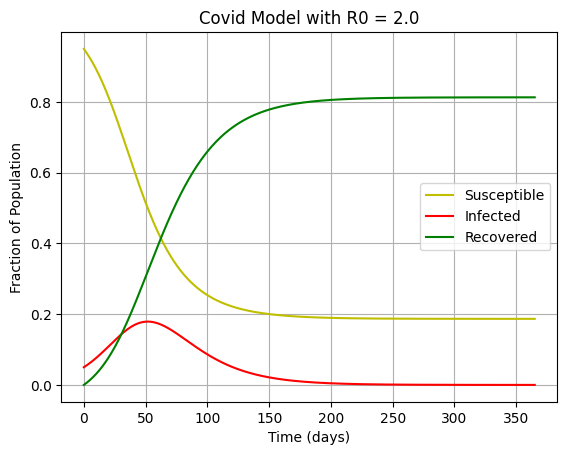

In [103]:
def COVID_model(y, t, beta, gamma):
    s, i, r = y
    dsdt = -beta * i * s
    didt = beta * i * s - gamma * i
    drdt = gamma * i
    return [dsdt, didt, drdt]

i0 = 0.05
beta0 = 0.1
gamma0 = 0.05
R0 = beta0 / gamma0
s0 = 1 - i0  
r0 = 0.0    

t = np.linspace(0, 365, 1000)

solution = odeint(COVID_model, [s0, i0, r0], t, args=(beta0, gamma0))
s, i, r = np.transpose(solution)

plt.plot(t, s, 'y', label='Susceptible')
plt.plot(t, i, 'r', label='Infected')
plt.plot(t, r, 'g', label='Recovered')
plt.xlabel('Time (days)')
plt.ylabel('Fraction of Population')
plt.title(f'Covid Model with R0 = {R0}')
plt.legend()
plt.grid()
plt.show()

i.) This horizontally shifts the graph to the left and shrinks it.

ii.) This affects the end and beginning behaviors of the curves, leaving some people as always infected...

iii.) This affects the swiftness of having a population recover, if everyone has it, the quicker the whole population will recover.

3. Bouncing Ball
In a previous assignment, you looked at a ball thrown into the air
with initial velocity v0 from an initial height h, and tracked its vertical
position as it was falling under gravity, F = −mg. Using Newton’s
second law, F = ma, the equation of motion of the ball can be written
as a second order differential equation in the vertical position z:

m
d
2
z
dt2
= −mg

where g = 9.8m/s2
.

(a) 5 points Set an initial height h, initial vertical velocity v0, and
solve the equation of motion of the ball using odeint. Choose a
time duration long enough so that you can see the ball go up into
the air, return to the ground, and keep going a little longer.Plot
vertical position z vs time t. Remember to label your axes, with
units, and give your graph a title.

(b) 10 points When you plotted the ball’s vertical position as a func-
tion of time, the ball kept going past the ground. In reality, this

would not happen - the ball would feel a force from the ground on
impact, and this force in turn would propel it back into the air.
How do we take this into account?
One possible model for the contact force is F = −kz−γv for z < 0.

This includes a spring-like force (proportional to k) and a damp-
ing force (proportional to the velocity with damping constant γ)

which allows for energy loss with each bounce. Add this into your
differential equation, and solve for a length of time long enough
so you can see at least two bounces. Note: this force should only
come into play when the ball is in contact with the ground, i.e.
when z < 0. Plot vertical position z vs time t. Remember to label
your axes, with units, and give your graph a title.
Use mass of the ball m = 0.3 kg, spring constant k = 1×103N/m
and damping coefficient γ = 1.0Ns/m

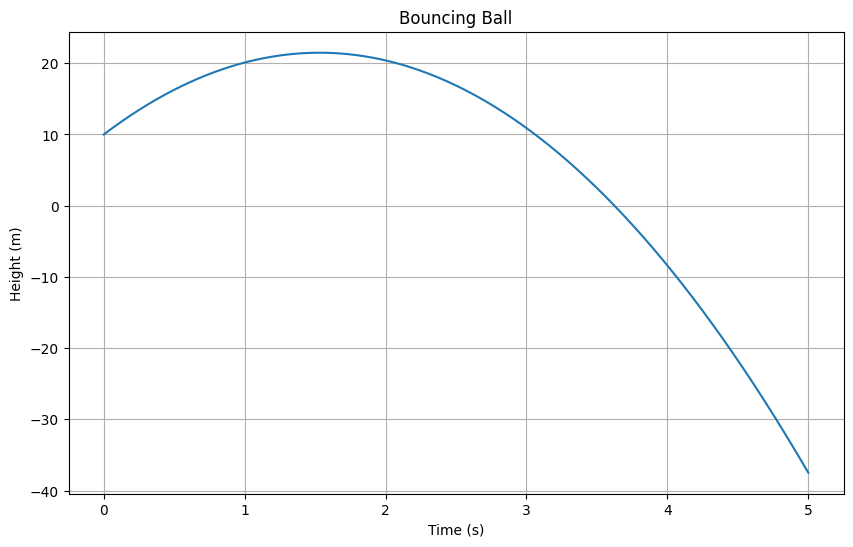

In [105]:
def bouncingball(y, t):
    z, v = y 
    dzdt = v
    dvdt = -9.8 
    return [dzdt, dvdt]

h0 = 10.0 
v0 = 15.0 
t = np.linspace(0, 5, 1000)  

solution = odeint(bouncingball, [h0, v0], t)
z = solution[:, 0]

plt.figure(figsize=(10, 6))
plt.plot(t, z)
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Bouncing Ball')
plt.grid()
plt.show()

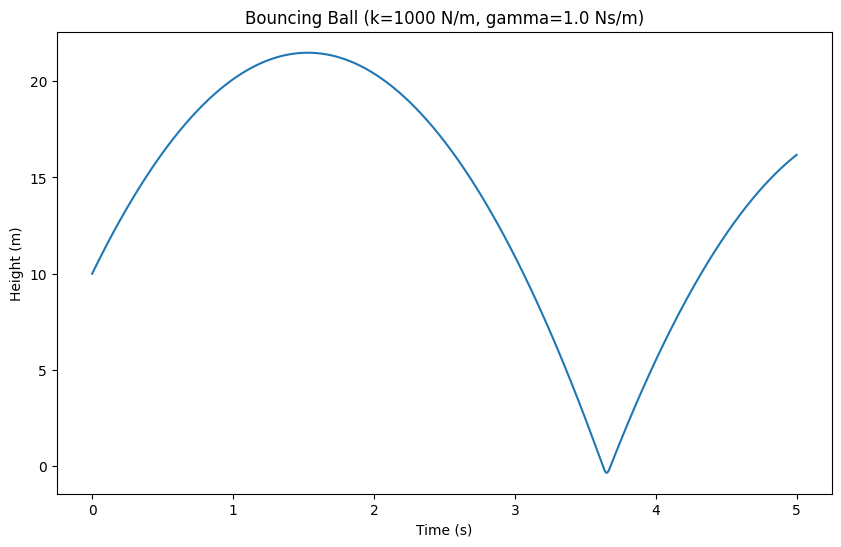

In [106]:
def bouncing_ball_return(y, t, m, k, gamma):
    z, v = y
    dzdt = v
    
    if z < 0: 
        dvdt = (-m * 9.8 - k * z - gamma * v) / m
    else:
        dvdt = -9.8
    return [dzdt, dvdt]

m = 0.3 
k = 1e3 
gamma = 1.0  

solution = odeint(bouncing_ball_return, [h0, v0], t, args=(m, k, gamma))
z2 = solution[:, 0]

plt.figure(figsize=(10, 6))
plt.plot(t, z2)
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title(f'Bouncing Ball (k={k:.0f} N/m, gamma={gamma} Ns/m)')
plt.show()

4. Driven, Damped, Nonlinear Pendulum
The equation of motion for a damped, driven, nonlinear pendulum of
length l is
d
2
θ
dt2
= −
g
l
sin θ − q
dθ
dt + FD sin(ΩDt)

This can be written as two linear ordinary differential equations (ODEs):

dθ
dt = ω (1)

dω
dt = −
g
l
sin θ − qω + FD sin(ΩDt) (2)

Set g/l = 1, ∆t = 0.01, q = 0.5, ΩD = 2/3.

(a) (10 points) Compute and plot θ(t) and ω(t) over the range 0 <
t < 100 s on the same graph with initial conditions at t = 0 of
θ(0) = 0.2 rad, ω(0) = 0 rad/s. Do this for three different values
of the driving force amplitude FD = 0, 0.5, 1.2. Use legends.

(b) (5 points) Next, adjust your angle so that it falls between −π and
π. To do this, make the following adjustment: if θ > π, then
θ → θ − 2π, else if θ < −π, then θ → θ + 2π. Plot θ vs time for
the previous three values of FD, on the same plot (use legends).
In a markdown cell, describe the changes in the plots.

(c) (5 points) Repeat for a second pendulum (i.e. define a new θ and
ω) . Keep everything the same, except change the starting value
of the angle: θ2(0) = 0.21 rad. Plot old and new on the same
graph for the same set of plots as in part 4a.

(d) (5 points) Plot ∆θ(t) = θ1(t) − θ2(t) as a function of time for all
three values of FD on the same graph (use legends). How does the
strength of the driving change the time dependence of the angle?

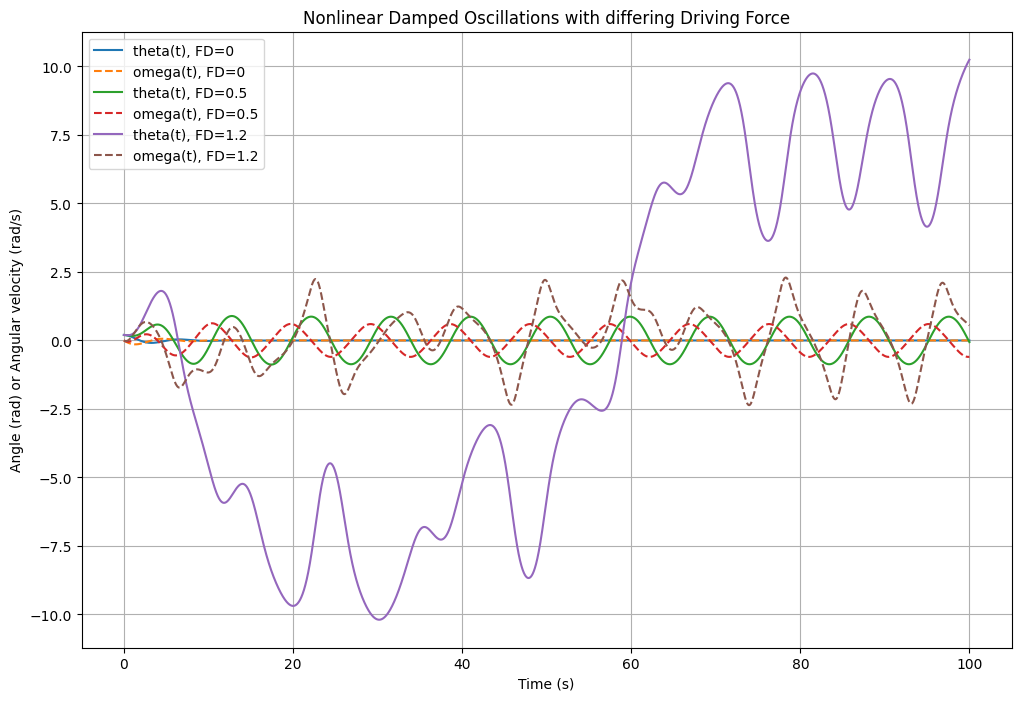

In [38]:
g = 9.8
l = 9.8
q = 0.5
omegaD = 2/3 
dt = 0.01 
t = np.arange(0, 100, dt) 

FD_values = [0, 0.5, 1.2]

def damped_nonlinear_pendulum(y, t, FD):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = - g / l * np.sin(theta) - q * omega + FD * np.sin(omegaD * t)
    return [dtheta_dt, domega_dt]

plt.figure(figsize=(12, 8))
for FD in FD_values:
    sol = odeint(damped_nonlinear_pendulum, [0.2, 0], t, args=(FD,))
    theta, omega = sol[:, 0], sol[:, 1]
    plt.plot(t, theta, label=f'theta(t), FD={FD}')
    plt.plot(t, omega, '--', label=f'omega(t), FD={FD}')

plt.xlabel('Time (s)')
plt.ylabel('Angle (rad) or Angular velocity (rad/s)')
plt.title('Nonlinear Damped Oscillations with differing Driving Force')
plt.legend()
plt.grid()
plt.show()

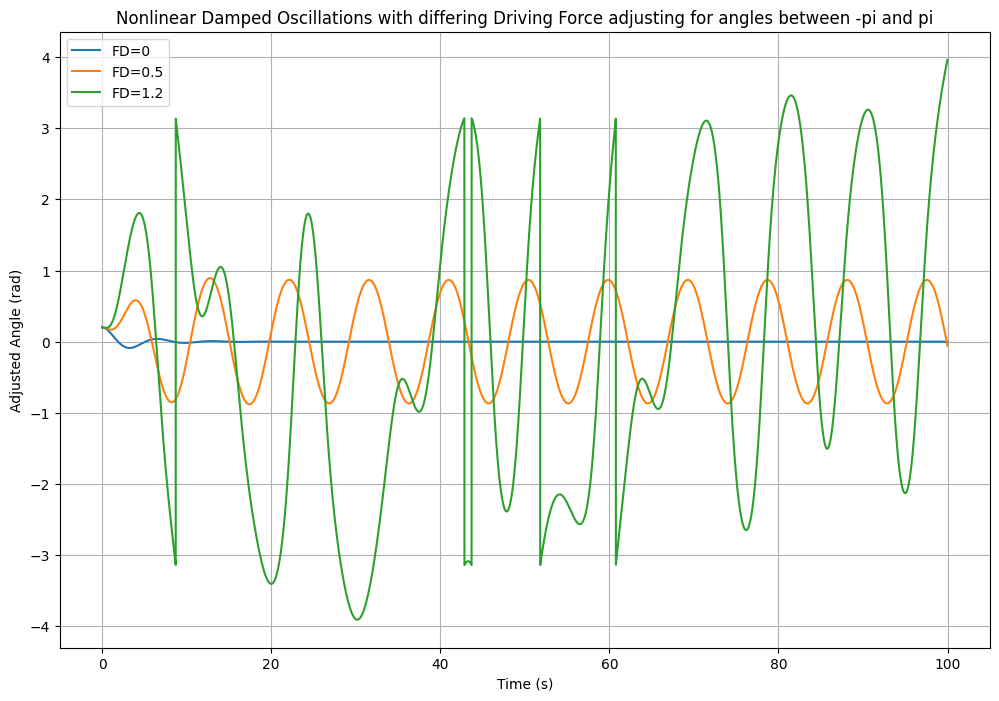

In [45]:
plt.figure(figsize=(12, 8))
for FD in FD_values:
    sol = odeint(damped_nonlinear_pendulum, [0.2, 0], t, args=(FD,))
    theta = sol[:, 0]
    theta_adjusted = np.zeros(len(theta))
    for i in range(len(theta)):
        if theta[i] > np.pi:
            theta_adjusted[i] = theta[i] - 2*np.pi
        elif theta[i] < -np.pi:
            theta_adjusted[i] = theta[i] + 2*np.pi
        else:
            theta_adjusted[i] = theta[i]
    plt.plot(t, theta_adjusted, label=f'FD={FD}')

plt.xlabel('Time (s)')
plt.ylabel('Adjusted Angle (rad)')
plt.title('Nonlinear Damped Oscillations with differing Driving Force adjusting for angles between -pi and pi')
plt.legend()
plt.grid()
plt.show()

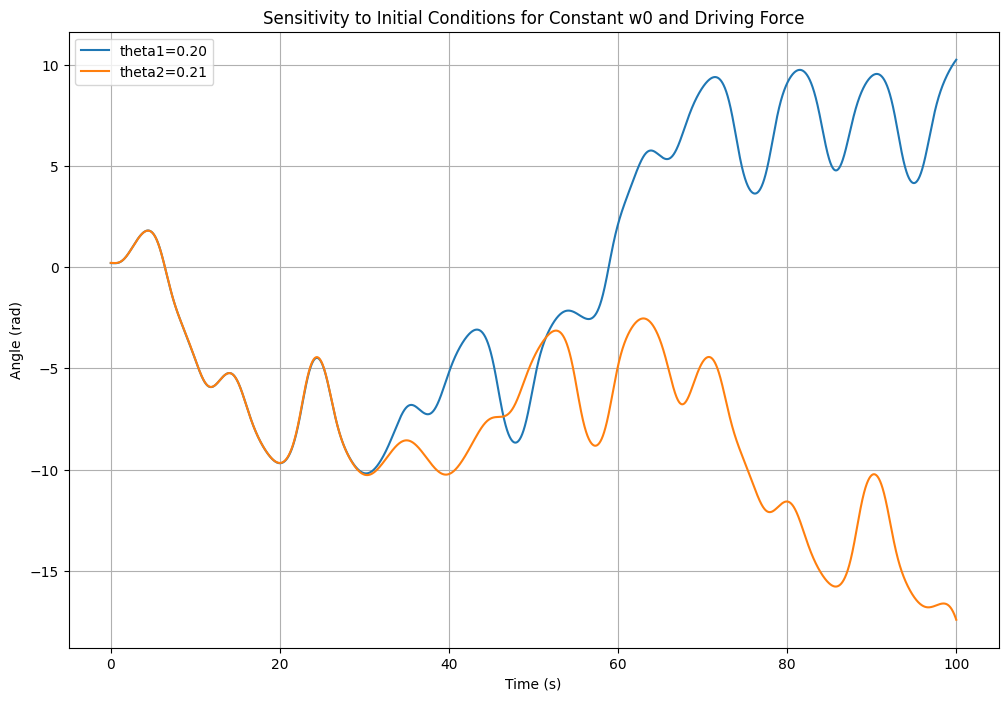

In [ ]:
plt.figure(figsize=(12, 8))
FD = 1.2  
sol1 = odeint(damped_nonlinear_pendulum, [0.20, 0], t, args=(FD,))
sol2 = odeint(damped_nonlinear_pendulum, [0.21, 0], t, args=(FD,))

plt.plot(t, sol1[:, 0], label='theta1=0.20')
plt.plot(t, sol2[:, 0], label='theta2=0.21')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('Sensitivity to Initial Conditions for Constant w0 and Driving Force')
plt.legend()
plt.grid()
plt.show()

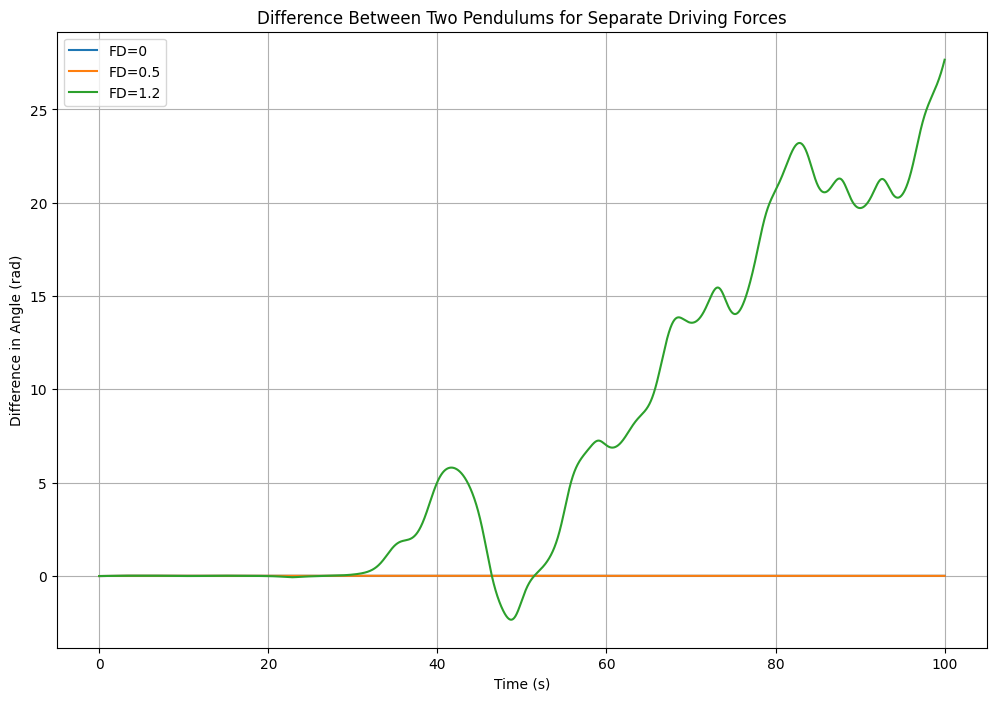

In [52]:
plt.figure(figsize=(12, 8))
for FD in FD_values:
    sol1 = odeint(damped_nonlinear_pendulum, [0.20, 0], t, args=(FD,))
    sol2 = odeint(damped_nonlinear_pendulum, [0.21, 0], t, args=(FD,))
    delta_theta = sol1[:, 0] - sol2[:, 0]
    plt.plot(t, delta_theta, label=f'FD={FD}')

plt.xlabel('Time (s)')
plt.ylabel('Difference in Angle (rad)')
plt.title('Difference Between Two Pendulums for Separate Driving Forces')
plt.legend()
plt.grid()
plt.show()

5. Solving an ODE with odeint: The low-pass filter. The circuit
shown in the attached figure built from a resistor R and a capacitor C
is called a “low-pass filter”. The input voltage Vin(t) is specified. Then
the output voltage Vout(t) is determined by the following first-order
ODE:

dVout(t)
dt =
Vin(t) − Vout(t)
RC .
4

This is called a low-pass filter because low-frequency sine waves with

angular frequencies ω  1/RC pass through this circuit nearly un-
changed, while high frequency sine waves with ω  1/RC are (imper-
fectly) blocked. For this problem use R = 10 kΩ, C = 1 μF which gives

1/RC = 100 rad/s.

(a) (5 points) Assume Vin(t) = A sin(ωt) with A = 2.0 V and ω =
50 rad/s. Define a function to compute Vin(t) and use this function
to make a plot of Vin(t) for 0 < t < tmax, with tmax chosen to show
about two or three complete cycles of the sine wave. Make the
number of time points a variable that you can easily change. Start
with several hundred points to get a nice smooth curve.

(b) (5 points) Write a program to that uses odeint to find Vout(t) at the
same set of time points. Use the initial condition Vout(0) = 0.0 V.
Plot Vin(t) and Vout(t) on the same graph (with labeled axes and a
legend for the two curves). Because ω < 1/RC, the output should
be only a little bit smaller than the input and slightly shifted in
phase.

(c) (5 points) Run your program again, changing ω to 300 rad/s.
Now the output should be quite a bit smaller than the input, and
shifted in phase by nearly π/2. For both values of ω you should
find that Vout(t) is a sine wave except for an initial transient near
t = 0.

(d) (5 points) How would you modify the circuit to get a high-pass
filter? Answer in a markdown cell.

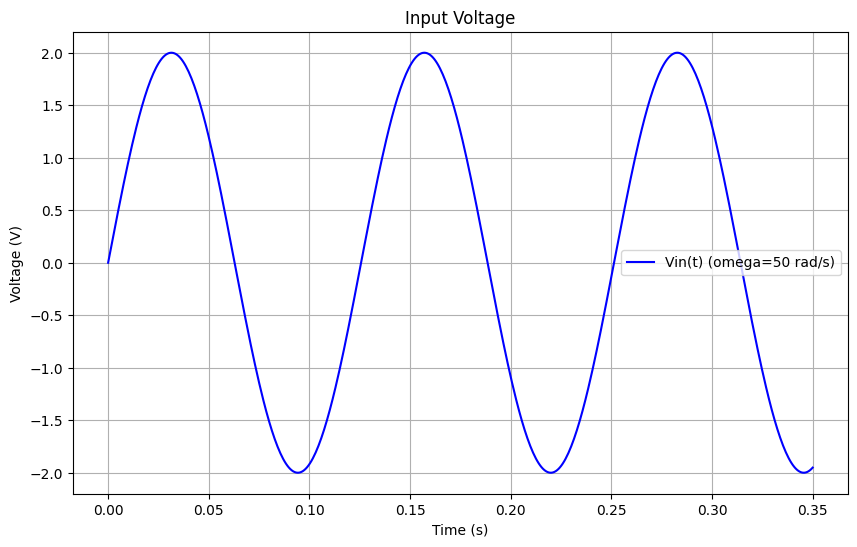

In [61]:
R = 10e3 
C = 1e-6  
RC = R * C
A = 2.0 
omega1 = 50  

tmax = 0.35
n_points = 500
t = np.linspace(0, tmax, n_points)

def Vin(t, omega):
    return A * np.sin(omega * t)

plt.figure(figsize=(10, 6))
plt.plot(t, Vin(t, omega1), 'b-', label=f'Vin(t) (omega={omega1} rad/s)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Input Voltage')
plt.grid()
plt.legend()
plt.show()

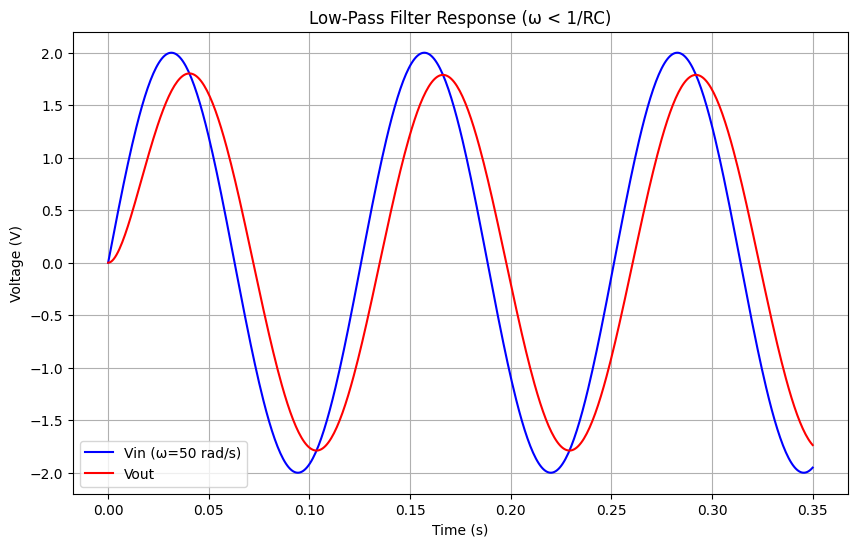

In [ ]:
def dVout_dt(Vout, t, omega):
    return (Vin(t, omega) - Vout) / RC

Vout = odeint(dVout_dt, 0.0, t, args=(omega1,))

plt.figure(figsize=(10, 6))
plt.plot(t, Vin(t, omega1), 'b-', label=f'Vin')
plt.plot(t, Vout, 'r', label='Vout')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Low-Pass Filter Response')
plt.grid()
plt.legend()
plt.show()

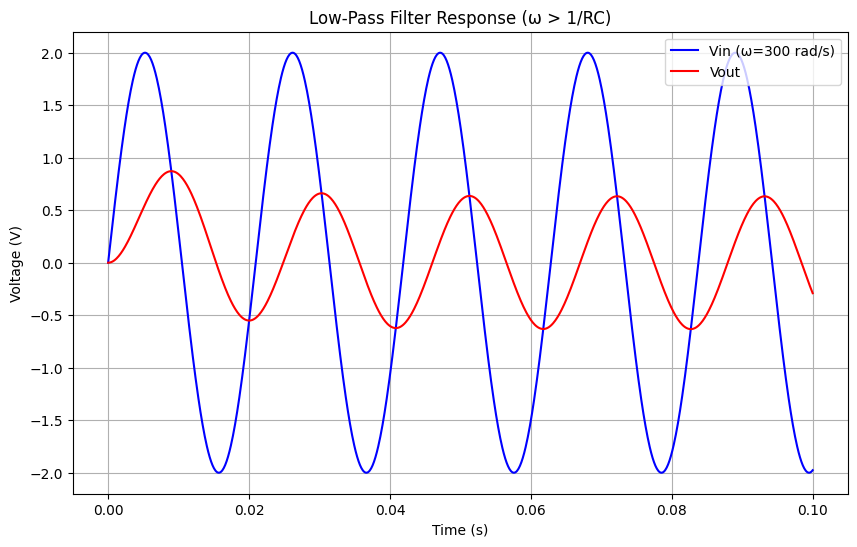

In [108]:
tmax = 0.1
t = np.linspace(0, tmax, n_points)
omega2 = 300

Vout2 = odeint(dVout_dt, 0.0, t, args=(omega2,))

plt.figure(figsize=(10, 6))
plt.plot(t, Vin(t, omega2), 'b-', label=f'Vin (ω={omega2} rad/s)')
plt.plot(t, Vout2, 'r-', label='Vout')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Low-Pass Filter Response (ω > 1/RC)')
plt.grid()
plt.legend()
plt.show()

In order to create a high pass filter we need to switch the order of the capacitor and the resistor so that the output voltage is over the resistor, flipping the differential equation, and thus, flipping its interpretation

6. Projectile motion (10 points) This returns to a problem you did
earlier in the semester, but using the differential equation version. For
a mass m launched with initial velocity v0 at angle θ with gravitational

5

acceleration g, Newton’s second law of motion (F = ma) for its position
~r = xˆi + yˆj is:

m
d
2x
dt2
= Fx,
m
d
2
y
dt2
= Fy

Write a program to simulate this ODE given Fx = 0 and Fy = mg.
Plot the results for x(t) and y(t) as a function of time t using either
scipy.integrate.odeint or your own RK2 code, then plot y(t) versus
x(t) on a separate plot. Label your axes.
Take m = 0.30 kg and use initial conditions y = 10m, v0 = 40.0 m/s
and θ = 30◦ at time t = 0. Does your result depend on the mass m?

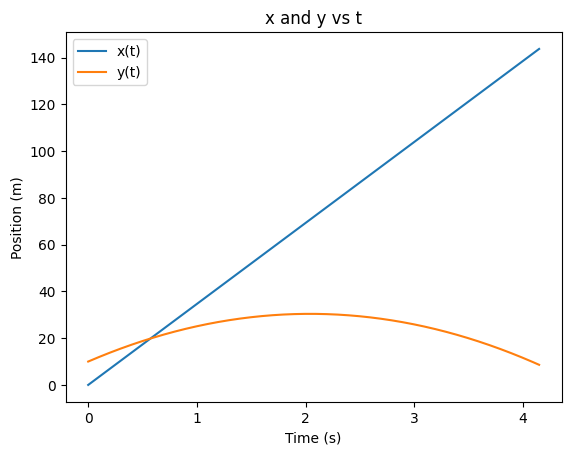

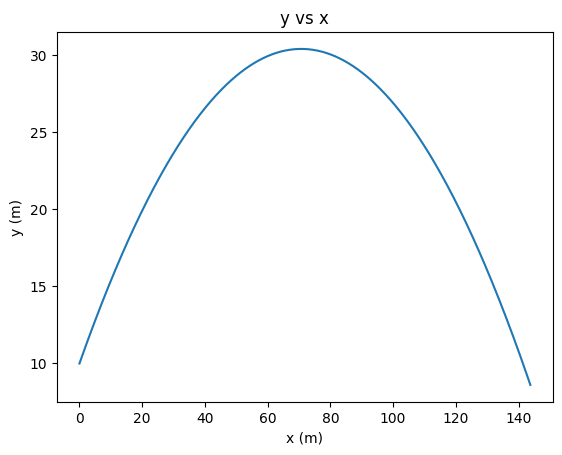

In [91]:
g = 9.8 
theta = np.radians(30)
v0 = 40.0 
y0 = 10.0 
m = 0.3 

x0 = 0.0
vx0 = v0 * np.cos(theta)
y0 = y0
vy0 = v0 * np.sin(theta)

def projectile_motion(s, t):
    x, vx, y, vy = s
    dxdt = vx
    dvxdt = 0
    dydt = vy
    dvydt = -g
    return [dxdt, dvxdt, dydt, dvydt]

t = np.linspace(0, 4.15, 500)

initial_conditions = [x0, vx0, y0, vy0]

sol = odeint(projectile_motion, initial_conditions, t)

x = sol[:, 0]
y = sol[:, 2]

plt.plot(t, x, label='x(t)')
plt.plot(t, y, label='y(t)')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.title('x and y vs t')
plt.show()

plt.plot(x, y)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('y vs x')
plt.show()


m does not matter bc gravity is independent of mass :P

8. Satellite in Low Earth Orbit
The orbits used by satellites as they circle the earth are separated into

three classes: High Earth Orbits (HEO) including geosynchronous or-
bits have an altitude in excess of 36,000 km; Mid Earth Orbits (MEO)

range in altitude from 2,000-36,000 km; and Low Earth Orbits (LEO)
range from 200-2,000 km. Examples of objects currently in LEO are the
International Space Station (altitude 300-400 km), the Hubble Space
Telescope (altitude 500 km), and many weather satellites. Objects in
LEO complete an orbit in an hour or two.
The net force on a satellite in a circular orbit at a height of 500 km above
the earths surface, neglectling the force of air drag on the satellite, is
given by the universal gravitational force from the earth:

F = −
GmM
r
2
rˆ

where r = RE + h is the position of the satellite, measured from the
origin at the center of the earth, RE = 6.3781 × 106

is the radius of

the Earth, G = 6.6743×10−11 m3/(kg s2

) is the universal gravitational
constant, ME = 5.9722 × 1024 kg is the mass of the earth, and m is
the mass of the satellite, which we will take to be 10,000 kg (this is
approximately the mass of the Hubble Space Telescope).

7

(a) (5 points) Using Newton’s second law, write an expression to find
the orbital speed that the satellite needs in order to maintain a
circular orbit at a height of h = 500 km. Note that, for what
follows, it is important to make your calculation using at least 5 significant figures - we need a highly-accurate orbital speed in or-
der to see relevant changes to the orbit on the order of kilometers. Put this into your code.

(b) (5 points) Divide your equations of motion into four first order
equations in (x, y) positions and velocities, and write code to
calculate all four as a function of time for an initial position and
velocity consistent with the orbit given in part (a).

(c) (5 points) For a duration corresponding to 5 complete orbits, make
two plots: the altitude (height above the earths surface, in km) of
the satellite as a function of time (in minutes or hours); and the
y position as a function of x-position.

In [69]:
G = 6.67430e-11 
M_earth = 5.9722e24 
R_earth = 6.3781e6 
m_sat = 10000
h = 500e3

r = R_earth + h

v_orbit = np.sqrt(G * M_earth / r)
print(f"Orbital velocity: {v_orbit:.5f} m/s")

T = 2 * np.pi * r / v_orbit
print(f"Orbital period: {T/60:.2f} minutes")

Orbital velocity: 7612.64873 m/s
Orbital period: 94.62 minutes


In [72]:
def satellite_motion(y, t):
    x, y, vx, vy = y
    r = np.sqrt(x**2 + y**2)
    ax = -G * M_earth * x / r**3
    ay = -G * M_earth * y / r**3
    return [vx, vy, ax, ay]

initial_conditions_a = [r, 0, 0, v_orbit]

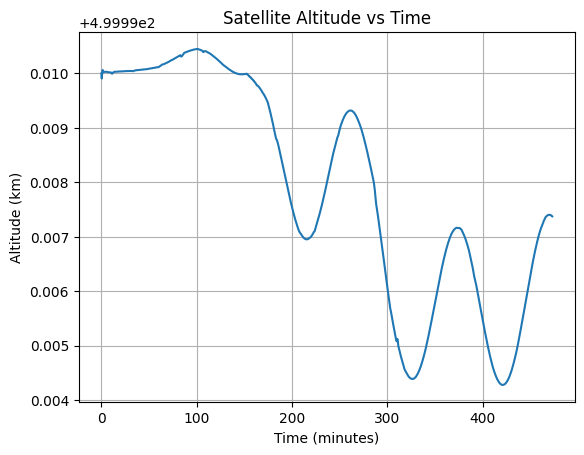

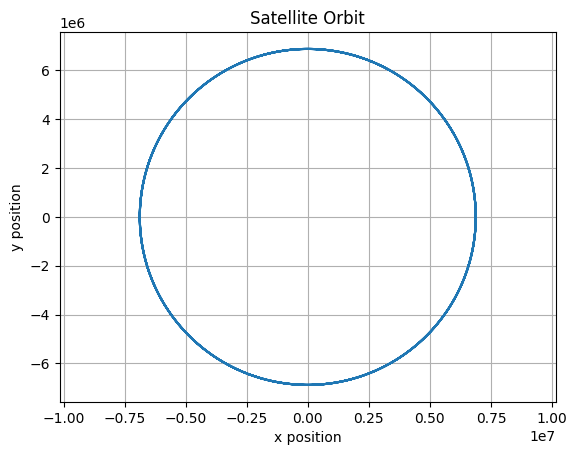

In [100]:
n_points = 1000
t_max = 5 * T
t = np.linspace(0, t_max, n_points)

solution = odeint(satellite_motion, initial_conditions_a, t)
x, y, vx, vy = np.transpose(solution)

altitude = (np.sqrt(x**2 + y**2) - R_earth)

altitude_km = altitude / 1000
t_minutes = t / 60

plt.plot(t_minutes, altitude_km)
plt.xlabel('Time (minutes)')
plt.ylabel('Altitude (km)')
plt.title('Satellite Altitude vs Time')
plt.grid()
plt.show()

plt.plot(x, y)
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Satellite Orbit')
plt.grid()
plt.axis("equal")
plt.show()